In [1]:

%pip install -r ../requirements.txt


from src.preprocessing import AudioPreprocessor
from src.data_augmentation import DataAugmentation
from src.augmented_dataset_generator import build_dataset


import kagglehub
import numpy as np
import matplotlib.pyplot as plt

import os
import IPython.display as ipd

import shutil




print("Custom modules loaded successfully!")




[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Custom modules loaded successfully!


In [2]:
path_to_raw_ravdess_dataset = "./data/raw_ravdess_audio_files"

# Download latest version
downloaded_path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", downloaded_path)

if not os.path.exists(path_to_raw_ravdess_dataset):
    shutil.move(downloaded_path, path_to_raw_ravdess_dataset)
    print(f"Success, raw ravdess dataset is now in: {path_to_raw_ravdess_dataset}")
else:
    print("Folder already exists, skipping.")


Resuming download from 31457280 bytes (418645610 bytes left)...
Resuming download to /Users/manumalakannavar/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/1.archive (31457280/450102890) bytes left.


100%|██████████| 429M/429M [00:18<00:00, 22.6MB/s] 

Extracting files...


Path to dataset files: /Users/manumalakannavar/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Folder already exists, skipping.


In [3]:

NPY_DIR = "./data/processed_spectrograms"
WAV_DIR = "./data/augmented_audio_files"

# Pass the 'path' from kagglehub straight into your script
build_dataset(path_to_raw_ravdess_dataset, NPY_DIR, WAV_DIR)

Starting dataset build. Processing files from ./data/raw_ravdess_audio_files...


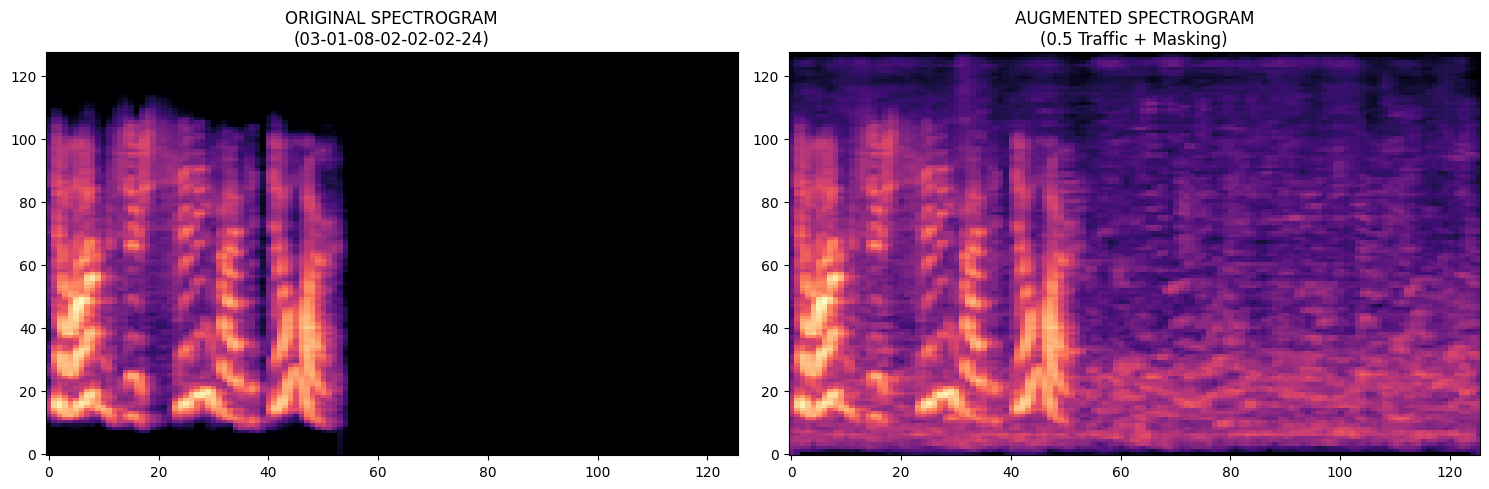

🔊 LISTEN TO THE AUGMENTED OUTPUT:


In [4]:


# --- HARDCODED TARGET ---
base_name = "03-01-08-02-02-02-24"
processed_dir = "data/processed_spectrograms"
aug_wav_dir = "data/augmented_audio_files"

# 1. Load the Spectrogram Arrays
orig_npy = os.path.join(processed_dir, f"orig_{base_name}.npy")
aug_npy = os.path.join(processed_dir, f"aug_{base_name}.npy")

# 2. Plotting the Spectrograms Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if os.path.exists(orig_npy) and os.path.exists(aug_npy):
    # Original Plot
    axes[0].imshow(np.load(orig_npy), aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title(f"ORIGINAL SPECTROGRAM\n({base_name})")
    
    # Augmented Plot
    axes[1].imshow(np.load(aug_npy), aspect='auto', origin='lower', cmap='magma')
    axes[1].set_title(f"AUGMENTED SPECTROGRAM\n(0.5 Traffic + Masking)")
else:
    print("❌ Check your paths! The .npy files weren't found.")

plt.tight_layout()
plt.show()

# 3. Audio Players
# If you don't have a raw folder, we skip the 'original' audio player 
# and just show the augmented one that YOU created.
aug_wav_path = os.path.join(aug_wav_dir, f"aug_{base_name}.wav")

if os.path.exists(aug_wav_path):
    print("🔊 LISTEN TO THE AUGMENTED OUTPUT:")
    ipd.display(ipd.Audio(aug_wav_path))
else:
    print(f"❌ Could not find: {aug_wav_path}")